In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# -----------------------------
# Helpers
# -----------------------------
def _setup_ax(ax, xlim, ylim):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")

def _make_closed_path(points):
    """points: (N,2) array, returns Path closed polygonal."""
    verts = np.vstack([points, points[0]])
    codes = [Path.MOVETO] + [Path.LINETO] * (len(points) - 1) + [Path.CLOSEPOLY]
    return Path(verts, codes)

def _add_domains(ax, path, face_inside="#4fe3c2", face_outside="#f2a324", alpha_in=0.95, alpha_out=0.95):
    """
    Fill exterior as a big rectangle, then cut out interior by layering:
    - draw outer rectangle (D-) as patch
    - draw interior (D+) as patch above it
    """
    # Big rectangle for outside
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    rect = np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]])
    rect_path = _make_closed_path(rect)
    outside = PathPatch(rect_path, facecolor=face_outside, edgecolor="none", alpha=alpha_out, zorder=0)
    inside = PathPatch(path, facecolor=face_inside, edgecolor="none", alpha=alpha_in, zorder=1)
    ax.add_patch(outside)
    ax.add_patch(inside)

def _animate_curve(points, out_gif, title=None, fps=30, seconds=3.0, dpi=140, transparent=False):
    """
    points: (N,2) closed curve sampling
    """
    nframes = int(fps * seconds)
    N = len(points)

    # Figure
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    # set limits with margin
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    mx = 0.20 * (xmax - xmin + 1e-9)
    my = 0.20 * (ymax - ymin + 1e-9)
    _setup_ax(ax, (xmin - mx, xmax + mx), (ymin - my, ymax + my))

    # Fill domains
    path = _make_closed_path(points)
    _add_domains(ax, path)

    # Curve line (progressive)
    line, = ax.plot([], [], lw=3.0, color="#1f3cff", zorder=3)

    if title:
        ax.text(0.02, 0.98, title, transform=ax.transAxes, ha="left", va="top",
                fontsize=14, fontstyle="italic", color="black", zorder=10)

    # Animation function
    def init():
        line.set_data([], [])
        return (line,)

    def update(frame):
        # progressive index
        t = frame / max(1, (nframes - 1))
        m = int(2 + t * (N - 1))
        xs = points[:m, 0]
        ys = points[:m, 1]
        line.set_data(xs, ys)
        return (line,)

    anim = FuncAnimation(fig, update, frames=nframes, init_func=init, blit=True)

    # Save GIF
    writer = PillowWriter(fps=fps)
    anim.save(out_gif, writer=writer, dpi=dpi, savefig_kwargs={"transparent": transparent})
    plt.close(fig)

# -----------------------------
# Example curves
# -----------------------------
def curve_star_cusps(n=2500, m=5, a=0.65):
    """
    Star-like curve with outward cusps at m points.
    Polar: r(θ) = 1 - a*cos(mθ)
    When a≈1, produces sharp outward spikes (cusp-like).
    """
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    r = 1.0 - a * np.cos(m * theta)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])

def curve_heart_inward_cusp(n=2500):
    """
    Heart-like curve with an inward cusp at the top center.
    A classic parametric heart:
      x = 16 sin^3 t
      y = 13 cos t - 5 cos 2t - 2 cos 3t - cos 4t
    Scaled down.
    """
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = 16 * (np.sin(t) ** 3)
    y = 13*np.cos(t) - 5*np.cos(2*t) - 2*np.cos(3*t) - np.cos(4*t)
    x /= 18.0
    y /= 18.0
    return np.column_stack([x, y])

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    # 1) Outward cusps (all)
    pts_star = curve_star_cusps(n=3000, m=5, a=0.85)
    _animate_curve(
        pts_star,
        out_gif="example_star_outward_cusps.gif",
        title="",
        fps=30,
        seconds=3.0,
        dpi=160,
        transparent=False,  # pon True si quieres fondo transparente (pierdes el relleno D-/D+)
    )

    # 2) Inward cusp (one)
    pts_heart = curve_heart_inward_cusp(n=3000)
    _animate_curve(
        pts_heart,
        out_gif="example_heart_inward_cusp.gif",
        title="",
        fps=30,
        seconds=3.0,
        dpi=160,
        transparent=False,
    )

    print("Listo: example_star_outward_cusps.gif y example_heart_inward_cusp.gif")

Listo: example_star_outward_cusps.gif y example_heart_inward_cusp.gif


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# -----------------------------
# Helpers
# -----------------------------
def setup_ax(ax, xlim, ylim):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")

def make_closed_path(points):
    verts = np.vstack([points, points[0]])
    codes = [Path.MOVETO] + [Path.LINETO] * (len(points) - 1) + [Path.CLOSEPOLY]
    return Path(verts, codes)

def add_domains(ax, closed_path, inside="#4fe3c2", outside="#f2a324", alpha_in=0.95, alpha_out=0.95):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    rect = np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]])
    rect_path = make_closed_path(rect)
    ax.add_patch(PathPatch(rect_path, facecolor=outside, edgecolor="none", alpha=alpha_out, zorder=0))
    ax.add_patch(PathPatch(closed_path, facecolor=inside, edgecolor="none", alpha=alpha_in, zorder=1))

def animate_polyline(points, out_gif, title=None, fill_closed=False, fps=30, seconds=3.0, dpi=160):
    """
    points: (N,2) samples along arc/curve. If fill_closed=True, assume curve closed.
    """
    nframes = int(fps * seconds)
    N = len(points)

    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    mx = 0.20 * (xmax - xmin + 1e-9)
    my = 0.20 * (ymax - ymin + 1e-9)
    setup_ax(ax, (xmin - mx, xmax + mx), (ymin - my, ymax + my))

    if fill_closed:
        path = make_closed_path(points)
        add_domains(ax, path)

    line, = ax.plot([], [], lw=3.0, color="#1f3cff", zorder=3)
    knots_scatter = ax.scatter([], [], s=36, facecolors="white", edgecolors="black", zorder=5)

    if title:
        ax.text(0.02, 0.98, title, transform=ax.transAxes, ha="left", va="top",
                fontsize=14, fontstyle="italic", color="black", zorder=10)

    # We'll mark knots provided via global list on the function object:
    knots = getattr(animate_polyline, "_knots", None)

    def init():
        line.set_data([], [])
        knots_scatter.set_offsets(np.empty((0,2)))
        return (line, knots_scatter)

    def update(frame):
        t = frame / max(1, (nframes - 1))
        m = int(2 + t * (N - 1))
        seg = points[:m]
        line.set_data(seg[:,0], seg[:,1])

        if knots is not None:
            # show only knots already "reached"
            # compute index reach by nearest along sampled polyline
            reached = []
            for kpt in knots:
                # find nearest index in whole points, and check if <= m
                d = np.sum((points - kpt)**2, axis=1)
                idx = int(np.argmin(d))
                if idx <= m:
                    reached.append(kpt)
            if reached:
                knots_scatter.set_offsets(np.array(reached))
            else:
                knots_scatter.set_offsets(np.empty((0,2)))

        return (line, knots_scatter)

    anim = FuncAnimation(fig, update, frames=nframes, init_func=init, blit=True)
    anim.save(out_gif, writer=PillowWriter(fps=fps), dpi=dpi)
    plt.close(fig)

# -----------------------------
# Build a piecewise Lyapunov ARC (open)
# Each piece is a rotated graph x + i f_k(x)
# -----------------------------
def piecewise_arc_samples():
    pieces = []
    knots = []

    # Piece 1: y = 0.35 sin(2x), x in [0, 1.6], no rotation
    x1 = np.linspace(0.0, 1.6, 650)
    y1 = 0.35*np.sin(2.0*x1)
    p1 = np.column_stack([x1, y1])
    pieces.append(p1)
    knots.append(p1[-1])

    # Piece 2: rotated graph around the knot
    # Build in local coords u in [0,1.2], v = 0.25 u^2 (smooth)
    u2 = np.linspace(0.0, 1.2, 520)
    v2 = 0.25*(u2**2)
    local2 = np.column_stack([u2, v2])
    theta2 = np.deg2rad(40.0)
    R2 = np.array([[np.cos(theta2), -np.sin(theta2)],
                   [np.sin(theta2),  np.cos(theta2)]])
    p2 = (local2 @ R2.T) + pieces[-1][-1]  # translate to connect
    pieces.append(p2)
    knots.append(p2[-1])

    # Piece 3: another rotated graph, with a mild "corner" at the join (still C1 on each piece)
    u3 = np.linspace(0.0, 1.3, 560)
    v3 = -0.18*np.sin(2.5*u3) + 0.12*u3
    local3 = np.column_stack([u3, v3])
    theta3 = np.deg2rad(-35.0)
    R3 = np.array([[np.cos(theta3), -np.sin(theta3)],
                   [np.sin(theta3),  np.cos(theta3)]])
    p3 = (local3 @ R3.T) + pieces[-1][-1]
    pieces.append(p3)

    # Full arc
    arc = np.vstack([pieces[0], pieces[1][1:], pieces[2][1:]])
    # endpoints + internal knots
    endpoints = [arc[0], arc[-1]]
    all_knots = endpoints + knots  # include joins
    return arc, all_knots

# -----------------------------
# Build a piecewise Lyapunov CURVE (closed Jordan)
# We'll create 4 smooth arcs and join them; the join points are singular.
# -----------------------------
def piecewise_curve_samples():
    pieces = []
    knots = []

    # We'll place 4 knots roughly like a rounded diamond
    c1 = np.array([ 0.0,  1.1])
    c2 = np.array([ 1.5,  0.0])
    c3 = np.array([ 0.0, -1.0])
    c4 = np.array([-1.4,  0.1])
    knots = [c1, c2, c3, c4]

    # Arc c1->c2 (bulge outward)
    t = np.linspace(0, 1, 600)
    p12 = (1-t)[:,None]*c1 + t[:,None]*c2
    p12 += np.column_stack([0.0*t, 0.45*np.sin(np.pi*t)])  # bulge in y
    pieces.append(p12)

    # Arc c2->c3
    t = np.linspace(0, 1, 600)
    p23 = (1-t)[:,None]*c2 + t[:,None]*c3
    p23 += np.column_stack([0.35*np.sin(np.pi*t), 0.0*t])  # bulge in x
    pieces.append(p23)

    # Arc c3->c4
    t = np.linspace(0, 1, 600)
    p34 = (1-t)[:,None]*c3 + t[:,None]*c4
    p34 += np.column_stack([0.0*t, -0.40*np.sin(np.pi*t)])  # bulge in y
    pieces.append(p34)

    # Arc c4->c1
    t = np.linspace(0, 1, 600)
    p41 = (1-t)[:,None]*c4 + t[:,None]*c1
    p41 += np.column_stack([-0.30*np.sin(np.pi*t), 0.0*t])  # bulge in x
    pieces.append(p41)

    curve = np.vstack([pieces[0],
                       pieces[1][1:],
                       pieces[2][1:],
                       pieces[3][1:]])
    return curve, knots

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    # 1) ARC (open)
    arc_pts, arc_knots = piecewise_arc_samples()
    animate_polyline._knots = arc_knots  # hack: pass knots to animator
    animate_polyline(
        arc_pts,
        out_gif="arc_lyapunov_piecewise.gif",
        title="Arco de Lyapunov a trozos",
        fill_closed=False,
        fps=30,
        seconds=3.2,
        dpi=160,
    )

    # 2) CURVE (closed)
    curve_pts, curve_knots = piecewise_curve_samples()
    animate_polyline._knots = curve_knots
    animate_polyline(
        curve_pts,
        out_gif="curve_lyapunov_piecewise.gif",
        title="Curva de Lyapunov a trozos",
        fill_closed=True,
        fps=30,
        seconds=3.2,
        dpi=160,
    )

    print("Listo: arc_lyapunov_piecewise.gif y curve_lyapunov_piecewise.gif")

Listo: arc_lyapunov_piecewise.gif y curve_lyapunov_piecewise.gif


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# -----------------------------
# Example: two smooth arcs meeting at c with a corner (singular point)
# We'll build Γ_- ending at c and Γ_+ starting at c.
# -----------------------------
def build_two_arcs(n=1200):
    c = np.array([0.0, 0.0])

    # Left arc Γ_- : param s in [0,1], ends at c
    s = np.linspace(0, 1, n)
    x1 = -1.8 + 1.8*s
    y1 = 0.35*np.sin(1.5*np.pi*s) * (1 - 0.15*s)
    gamma_minus = np.column_stack([x1, y1])
    gamma_minus[-1] = c

    # Right arc Γ_+ : param t in [0,1], starts at c
    t = np.linspace(0, 1, n)
    x2 = 1.6*t
    y2 = 0.55*(t**2) - 0.10*np.sin(2*np.pi*t)
    # rotate to make a visible corner
    theta = np.deg2rad(35)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    gamma_plus = (np.column_stack([x2, y2]) @ R.T)
    gamma_plus[0] = c

    return c, gamma_minus, gamma_plus

def unit(v):
    nv = np.linalg.norm(v)
    if nv == 0:
        return v
    return v / nv

# -----------------------------
# Animation: show z_-(k) and z_+(k) approaching c,
# and arrows for (z-c)/|z-c|
# -----------------------------
def make_gif(out_gif="tangentes_laterales.gif", fps=30, seconds=4.0):
    c, gm, gp = build_two_arcs()

    # full curve for background (concatenate, avoid duplicate c)
    curve = np.vstack([gm, gp[1:]])

    # figure limits
    xmin, ymin = curve.min(axis=0)
    xmax, ymax = curve.max(axis=0)
    mx = 0.25*(xmax-xmin+1e-9)
    my = 0.25*(ymax-ymin+1e-9)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin-mx, xmax+mx)
    ax.set_ylim(ymin-my, ymax+my)
    ax.axis("off")

    # static curve (thin)
    ax.plot(curve[:,0], curve[:,1], lw=2.5, color="#1f3cff", zorder=2)

    # mark c
    ax.scatter([c[0]], [c[1]], s=50, facecolors="white", edgecolors="black", zorder=5)
    ax.text(c[0]+0.05, c[1]+0.05, r"$c$", fontsize=14)

    # moving points z_-, z_+
    p_minus = ax.scatter([], [], s=40, color="black", zorder=6)
    p_plus  = ax.scatter([], [], s=40, color="black", zorder=6)

    # arrows for direction vectors (as quiver)
    q_minus = ax.quiver([], [], [], [], angles="xy", scale_units="xy", scale=1,
                        width=0.008, zorder=7)
    q_plus  = ax.quiver([], [], [], [], angles="xy", scale_units="xy", scale=1,
                        width=0.008, zorder=7)

    # labels τ_-, τ_+
    txt_minus = ax.text(0,0,"", fontsize=14, zorder=8)
    txt_plus  = ax.text(0,0,"", fontsize=14, zorder=8)

    # frames
    nframes = int(fps*seconds)

    # choose indices approaching c: from far to near
    idxs = np.linspace(60, len(gm)-2, nframes).astype(int)  # approach gm[-1]=c
    jdxs = np.linspace(60, len(gp)-2, nframes).astype(int)  # approach gp[0]=c from the right

    # arrow length
    L = 0.55

    def init():
        return (p_minus, p_plus, q_minus, q_plus, txt_minus, txt_plus)

    def update(k):
        i = idxs[k]
        j = jdxs[k]

        z_minus = gm[i]
        z_plus  = gp[j]

        v_minus = unit(z_minus - c) * L
        v_plus  = unit(z_plus - c) * L

        # update points
        p_minus.set_offsets([z_minus])
        p_plus.set_offsets([z_plus])

        # update quivers by re-creating (matplotlib quiver update is clunky)
        nonlocal q_minus, q_plus
        q_minus.remove()
        q_plus.remove()
        q_minus = ax.quiver(c[0], c[1], v_minus[0], v_minus[1],
                            angles="xy", scale_units="xy", scale=1,
                            width=0.008, color="black", zorder=7)
        q_plus  = ax.quiver(c[0], c[1], v_plus[0], v_plus[1],
                            angles="xy", scale_units="xy", scale=1,
                            width=0.008, color="black", zorder=7)

        # place labels near arrow tips
        txt_minus.set_position((c[0] + v_minus[0]*1.05, c[1] + v_minus[1]*1.05))
        txt_minus.set_text(r"$\frac{z-c}{|z-c|}\ (z\in\Gamma_-)$")
        txt_plus.set_position((c[0] + v_plus[0]*1.05, c[1] + v_plus[1]*1.05))
        txt_plus.set_text(r"$\frac{z-c}{|z-c|}\ (z\in\Gamma_+)$")

        return (p_minus, p_plus, q_minus, q_plus, txt_minus, txt_plus)

    anim = FuncAnimation(fig, update, frames=nframes, init_func=init, blit=False)
    anim.save(out_gif, writer=PillowWriter(fps=fps), dpi=170)
    plt.close(fig)

if __name__ == "__main__":
    make_gif()
    print("Listo: tangentes_laterales.gif")

Listo: tangentes_laterales.gif


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# -----------------------------
# Helpers
# -----------------------------
def setup_ax(ax, xlim, ylim):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")

def make_closed_path(points):
    verts = np.vstack([points, points[0]])
    codes = [Path.MOVETO] + [Path.LINETO] * (len(points) - 1) + [Path.CLOSEPOLY]
    return Path(verts, codes)

def add_domains(ax, closed_path, inside="#4fe3c2", outside="#f2a324", alpha_in=0.95, alpha_out=0.95):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    rect = np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]])
    rect_path = make_closed_path(rect)
    ax.add_patch(PathPatch(rect_path, facecolor=outside, edgecolor="none", alpha=alpha_out, zorder=0))
    ax.add_patch(PathPatch(closed_path, facecolor=inside, edgecolor="none", alpha=alpha_in, zorder=1))

def animate_polyline(points, out_gif, title=None, fill_closed=False, fps=30, seconds=3.0, dpi=160):
    """
    points: (N,2) samples along arc/curve. If fill_closed=True, assume curve closed.
    """
    nframes = int(fps * seconds)
    N = len(points)

    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    mx = 0.20 * (xmax - xmin + 1e-9)
    my = 0.20 * (ymax - ymin + 1e-9)
    setup_ax(ax, (xmin - mx, xmax + mx), (ymin - my, ymax + my))

    if fill_closed:
        path = make_closed_path(points)
        add_domains(ax, path)

    line, = ax.plot([], [], lw=3.0, color="#1f3cff", zorder=3)
    knots_scatter = ax.scatter([], [], s=36, facecolors="white", edgecolors="black", zorder=5)

    if title:
        ax.text(0.02, 0.98, title, transform=ax.transAxes, ha="left", va="top",
                fontsize=14, fontstyle="italic", color="black", zorder=10)

    # We'll mark knots provided via global list on the function object:
    knots = getattr(animate_polyline, "_knots", None)

    def init():
        line.set_data([], [])
        knots_scatter.set_offsets(np.empty((0,2)))
        return (line, knots_scatter)

    def update(frame):
        t = frame / max(1, (nframes - 1))
        m = int(2 + t * (N - 1))
        seg = points[:m]
        line.set_data(seg[:,0], seg[:,1])

        if knots is not None:
            # show only knots already "reached"
            # compute index reach by nearest along sampled polyline
            reached = []
            for kpt in knots:
                # find nearest index in whole points, and check if <= m
                d = np.sum((points - kpt)**2, axis=1)
                idx = int(np.argmin(d))
                if idx <= m:
                    reached.append(kpt)
            if reached:
                knots_scatter.set_offsets(np.array(reached))
            else:
                knots_scatter.set_offsets(np.empty((0,2)))

        return (line, knots_scatter)

    anim = FuncAnimation(fig, update, frames=nframes, init_func=init, blit=True)
    anim.save(out_gif, writer=PillowWriter(fps=fps), dpi=dpi)
    plt.close(fig)

# -----------------------------
# Build a piecewise Lyapunov ARC (open)
# Each piece is a rotated graph x + i f_k(x)
# -----------------------------
def piecewise_arc_samples():
    pieces = []
    knots = []

    # Piece 1: y = 0.35 sin(2x), x in [0, 1.6], no rotation
    x1 = np.linspace(0.0, 1.6, 650)
    y1 = 0.35*np.sin(2.0*x1)
    p1 = np.column_stack([x1, y1])
    pieces.append(p1)
    knots.append(p1[-1])

    # Piece 2: rotated graph around the knot
    # Build in local coords u in [0,1.2], v = 0.25 u^2 (smooth)
    u2 = np.linspace(0.0, 1.2, 520)
    v2 = 0.25*(u2**2)
    local2 = np.column_stack([u2, v2])
    theta2 = np.deg2rad(40.0)
    R2 = np.array([[np.cos(theta2), -np.sin(theta2)],
                   [np.sin(theta2),  np.cos(theta2)]])
    p2 = (local2 @ R2.T) + pieces[-1][-1]  # translate to connect
    pieces.append(p2)
    knots.append(p2[-1])

    # Piece 3: another rotated graph, with a mild "corner" at the join (still C1 on each piece)
    u3 = np.linspace(0.0, 1.3, 560)
    v3 = -0.18*np.sin(2.5*u3) + 0.12*u3
    local3 = np.column_stack([u3, v3])
    theta3 = np.deg2rad(-35.0)
    R3 = np.array([[np.cos(theta3), -np.sin(theta3)],
                   [np.sin(theta3),  np.cos(theta3)]])
    p3 = (local3 @ R3.T) + pieces[-1][-1]
    pieces.append(p3)

    # Full arc
    arc = np.vstack([pieces[0], pieces[1][1:], pieces[2][1:]])
    # endpoints + internal knots
    endpoints = [arc[0], arc[-1]]
    all_knots = endpoints + knots  # include joins
    return arc, all_knots

# -----------------------------
# Build a piecewise Lyapunov CURVE (closed Jordan)
# We'll create 4 smooth arcs and join them; the join points are singular.
# -----------------------------
def piecewise_curve_samples():
    pieces = []
    knots = []

    # We'll place 4 knots roughly like a rounded diamond
    c1 = np.array([ 0.0,  1.1])
    c2 = np.array([ 1.5,  0.0])
    c3 = np.array([ 0.0, -1.0])
    c4 = np.array([-1.4,  0.1])
    knots = [c1, c2, c3, c4]

    # Arc c1->c2 (bulge outward)
    t = np.linspace(0, 1, 600)
    p12 = (1-t)[:,None]*c1 + t[:,None]*c2
    p12 += np.column_stack([0.0*t, 0.45*np.sin(np.pi*t)])  # bulge in y
    pieces.append(p12)

    # Arc c2->c3
    t = np.linspace(0, 1, 600)
    p23 = (1-t)[:,None]*c2 + t[:,None]*c3
    p23 += np.column_stack([0.35*np.sin(np.pi*t), 0.0*t])  # bulge in x
    pieces.append(p23)

    # Arc c3->c4
    t = np.linspace(0, 1, 600)
    p34 = (1-t)[:,None]*c3 + t[:,None]*c4
    p34 += np.column_stack([0.0*t, -0.40*np.sin(np.pi*t)])  # bulge in y
    pieces.append(p34)

    # Arc c4->c1
    t = np.linspace(0, 1, 600)
    p41 = (1-t)[:,None]*c4 + t[:,None]*c1
    p41 += np.column_stack([-0.30*np.sin(np.pi*t), 0.0*t])  # bulge in x
    pieces.append(p41)

    curve = np.vstack([pieces[0],
                       pieces[1][1:],
                       pieces[2][1:],
                       pieces[3][1:]])
    return curve, knots

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    # 1) ARC (open)
    arc_pts, arc_knots = piecewise_arc_samples()
    animate_polyline._knots = arc_knots  # hack: pass knots to animator
    animate_polyline(
        arc_pts,
        out_gif="arc_lyapunov_piecewise.gif",
        title="Arco de Lyapunov a trozos",
        fill_closed=False,
        fps=30,
        seconds=3.2,
        dpi=160,
    )

    # 2) CURVE (closed)
    curve_pts, curve_knots = piecewise_curve_samples()
    animate_polyline._knots = curve_knots
    animate_polyline(
        curve_pts,
        out_gif="curve_lyapunov_piecewise.gif",
        title="Curva de Lyapunov a trozos",
        fill_closed=True,
        fps=30,
        seconds=3.2,
        dpi=160,
    )

    print("Listo: arc_lyapunov_piecewise.gif y curve_lyapunov_piecewise.gif")

Listo: arc_lyapunov_piecewise.gif y curve_lyapunov_piecewise.gif


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# 1) Geometría de ejemplo: dos arcos suaves que se pegan en c
#    (c es punto singular de una curva a trozos)
# ============================================================
def build_two_arcs(n=1400):
    c = np.array([0.0, 0.0])

    # Arco izquierdo Γ_- : termina en c
    s = np.linspace(0, 1, n)
    x1 = -2.0 + 2.0 * s
    y1 = 0.40 * np.sin(1.3 * np.pi * s) * (1 - 0.10 * s)
    gamma_minus = np.column_stack([x1, y1])
    gamma_minus[-1] = c

    # Arco derecho Γ_+ : empieza en c
    t = np.linspace(0, 1, n)
    x2 = 1.8 * t
    y2 = 0.55 * (t**2) - 0.08 * np.sin(2 * np.pi * t)

    # Rotación para crear una esquina visible
    theta = np.deg2rad(35.0)
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    gamma_plus = (np.column_stack([x2, y2]) @ R.T)
    gamma_plus[0] = c

    return c, gamma_minus, gamma_plus


def unit(v):
    nv = np.linalg.norm(v)
    return v if nv == 0 else (v / nv)


# ============================================================
# 2) Índices de aproximación geométrica (clave para estabilizar)
# ============================================================
def approach_indices(length, nframes, start_far=120, min_gap=2, rate=0.93):
    """
    Devuelve índices que se acercan a 'c' de forma geométrica.
    - start_far: índice inicial (más lejos)
    - min_gap: evita tocar exactamente el último/primero punto en c
    - rate: 0<rate<1. Más cerca a 1 => más fino al final (más estable)
    """
    last = length - 1 - min_gap   # índice casi en c
    first = int(start_far)

    gaps = (last - first) * (rate ** np.arange(nframes))   # decrece geométricamente
    idxs = (last - gaps).round().astype(int)

    idxs = np.clip(idxs, first, last)
    idxs = np.maximum.accumulate(idxs)  # asegura monotonicidad
    return idxs


# ============================================================
# 3) Animación: secantes unitarias que convergen a τ_- y τ_+
# ============================================================
def make_gif(out_gif="tangentes_laterales.gif", fps=30, seconds=4.0, rate=0.93):
    c, gm, gp = build_two_arcs()

    # Curva completa para mostrar contexto (Γ_- + Γ_+)
    curve = np.vstack([gm, gp[1:]])

    # Límites de figura
    xmin, ymin = curve.min(axis=0)
    xmax, ymax = curve.max(axis=0)
    mx = 0.25 * (xmax - xmin + 1e-9)
    my = 0.25 * (ymax - ymin + 1e-9)

    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.axis("off")

    # Curva (azul)
    ax.plot(curve[:, 0], curve[:, 1], lw=3.5, color="#1f3cff", zorder=2)

    # Punto singular c
    ax.scatter([c[0]], [c[1]], s=70, facecolors="white", edgecolors="black", zorder=6)
    ax.text(c[0] + 0.06, c[1] + 0.06, r"$c$", fontsize=16, zorder=7)

    # Puntos móviles z_- y z_+
    p_minus = ax.scatter([], [], s=55, color="black", zorder=7)
    p_plus  = ax.scatter([], [], s=55, color="black", zorder=7)

    # Flechas (quiver). Las recreamos en cada frame (simple y robusto)
    q_minus = None
    q_plus = None

    # Etiquetas de los vectores
    txt_minus = ax.text(0, 0, "", fontsize=15, zorder=8)
    txt_plus  = ax.text(0, 0, "", fontsize=15, zorder=8)

    # Frames
    nframes = int(fps * seconds)

    # Índices geométricos (se acercan MUCHO al final)
    idxs = approach_indices(len(gm), nframes, start_far=140, min_gap=2, rate=rate)
    jdxs = approach_indices(len(gp), nframes, start_far=140, min_gap=2, rate=rate)

    # Longitud de flecha
    L = 0.70

    # Para dibujar flechas finales fijas al final (opcional visual)
    show_final_from = int(0.70 * nframes)  # desde qué frame empiezas a mostrar “tangente final”
    final_tau_minus = unit(gm[idxs[-1]] - c)
    final_tau_plus  = unit(gp[jdxs[-1]] - c)

    final_q_minus = None
    final_q_plus = None

    def init():
        p_minus.set_offsets(np.empty((0, 2)))
        p_plus.set_offsets(np.empty((0, 2)))
        txt_minus.set_text("")
        txt_plus.set_text("")
        return (p_minus, p_plus, txt_minus, txt_plus)

    def update(k):
        nonlocal q_minus, q_plus, final_q_minus, final_q_plus

        i = idxs[k]
        j = jdxs[k]

        z_minus = gm[i]
        z_plus = gp[j]

        v_minus = unit(z_minus - c) * L
        v_plus = unit(z_plus - c) * L

        # Puntos
        p_minus.set_offsets([z_minus])
        p_plus.set_offsets([z_plus])

        # Borra flechas previas
        if q_minus is not None:
            q_minus.remove()
        if q_plus is not None:
            q_plus.remove()

        # Dibuja flechas secantes unitarias
        q_minus = ax.quiver(c[0], c[1], v_minus[0], v_minus[1],
                            angles="xy", scale_units="xy", scale=1,
                            width=0.010, color="black", zorder=7)
        q_plus = ax.quiver(c[0], c[1], v_plus[0], v_plus[1],
                           angles="xy", scale_units="xy", scale=1,
                           width=0.010, color="black", zorder=7)

        # Etiquetas cerca de las puntas
        txt_minus.set_position((c[0] + v_minus[0] * 1.08, c[1] + v_minus[1] * 1.08))
        txt_minus.set_text(r"$\frac{z-c}{|z-c|}\ (z\in\Gamma_-)$")

        txt_plus.set_position((c[0] + v_plus[0] * 1.08, c[1] + v_plus[1] * 1.08))
        txt_plus.set_text(r"$\frac{z-c}{|z-c|}\ (z\in\Gamma_+)$")

        # (Opcional) Mostrar las tangentes laterales "finales" como flechas fijas desde cierto frame
        if k == show_final_from:
            # dibuja flechas fijas en gris para indicar el límite τ_-(c), τ_+(c)
            if final_q_minus is not None:
                final_q_minus.remove()
            if final_q_plus is not None:
                final_q_plus.remove()

            final_q_minus = ax.quiver(c[0], c[1], final_tau_minus[0]*L, final_tau_minus[1]*L,
                                      angles="xy", scale_units="xy", scale=1,
                                      width=0.006, color="gray", zorder=6)
            final_q_plus = ax.quiver(c[0], c[1], final_tau_plus[0]*L, final_tau_plus[1]*L,
                                     angles="xy", scale_units="xy", scale=1,
                                     width=0.006, color="gray", zorder=6)
            ax.text(c[0] + final_tau_minus[0]*L*1.05, c[1] + final_tau_minus[1]*L*1.05,
                    r"$\tau_-(c)$", fontsize=14, color="gray", zorder=9)
            ax.text(c[0] + final_tau_plus[0]*L*1.05, c[1] + final_tau_plus[1]*L*1.05,
                    r"$\tau_+(c)$", fontsize=14, color="gray", zorder=9)

        return (p_minus, p_plus, q_minus, q_plus, txt_minus, txt_plus)

    anim = FuncAnimation(fig, update, frames=nframes, init_func=init, blit=False)
    anim.save(out_gif, writer=PillowWriter(fps=fps), dpi=170)
    plt.close(fig)


if __name__ == "__main__":
    make_gif(out_gif="tangentes_laterales.gif", fps=30, seconds=4.0, rate=0.93)
    print("Listo: tangentes_laterales.gif")

Listo: tangentes_laterales.gif


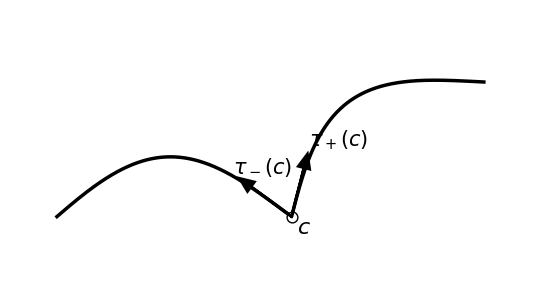

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def unit(v):
    n = np.linalg.norm(v)
    return v if n == 0 else v / n

# -----------------------------
# 1) Construye dos ramas que llegan a c
# -----------------------------
c = np.array([0.0, 0.0])

# Rama izquierda Γ_-: termina en c
s = np.linspace(0, 1, 600)
x_minus = -2.0 + 2.0 * s
y_minus = 0.55 * np.sin(np.pi * s) * (1 - 0.15 * s)
Gamma_minus = np.column_stack([x_minus, y_minus])
Gamma_minus[-1] = c

# Rama derecha Γ_+: empieza en c
t = np.linspace(0, 1, 600)
x_plus = 2.0 * t
y_plus = 0.55 * np.sin(np.pi * t) * (1 - 0.10 * t)

# rota un poco para que las tangentes laterales sean distintas (esquina)
theta = np.deg2rad(35)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
Gamma_plus = (np.column_stack([x_plus, y_plus]) @ R.T)
Gamma_plus[0] = c

# -----------------------------
# 2) Aproxima τ_-(c), τ_+(c) con puntos cercanos a c
# -----------------------------
# punto cercano a c por cada lado (no uses el último/primero para evitar 0)
z_minus = Gamma_minus[-6]
z_plus  = Gamma_plus[5]

tau_minus = unit(z_minus - c)
tau_plus  = unit(z_plus - c)

# -----------------------------
# 3) Dibuja
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

# curvas
ax.plot(Gamma_minus[:,0], Gamma_minus[:,1], lw=2.5, color="black")
ax.plot(Gamma_plus[:,0],  Gamma_plus[:,1],  lw=2.5, color="black")

# punto c
ax.scatter([c[0]], [c[1]], s=60, facecolors="white", edgecolors="black", zorder=5)
ax.text(c[0]+0.05, c[1]-0.15, r"$c$", fontsize=16)

# flechas tangentes laterales (desde c)
L = 0.55
ax.arrow(c[0], c[1], L*tau_minus[0], L*tau_minus[1],
         head_width=0.10, head_length=0.12, length_includes_head=True,
         color="black", lw=2.0, zorder=6)
ax.arrow(c[0], c[1], L*tau_plus[0], L*tau_plus[1],
         head_width=0.10, head_length=0.12, length_includes_head=True,
         color="black", lw=2.0, zorder=6)

# etiquetas
ax.text(c[0] + 0.62*tau_minus[0], c[1] + 0.62*tau_minus[1], r"$\tau_-(c)$", fontsize=15)
ax.text(c[0] + 0.62*tau_plus[0],  c[1] + 0.62*tau_plus[1],  r"$\tau_+(c)$", fontsize=15)

# límites
pts = np.vstack([Gamma_minus, Gamma_plus])
xmin, ymin = pts.min(axis=0)
xmax, ymax = pts.max(axis=0)
ax.set_xlim(xmin-0.4, xmax+0.4)
ax.set_ylim(ymin-0.6, ymax+0.6)

plt.show()